In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
)

Downloading bucket files: 89041311 / 89041311 complete

Downloading bytes: 89041311 / 89041311 complete

In [2]:
reader = scarf.CrH5Reader(f"{dataset}/data.h5")
reader.nCells, reader.nFeatures

(5025, 33538)

In [3]:
scarf.CrToZarr(
    reader,
    zarr_loc=f"{dataset}/data.zarr",
).dump()

In [4]:
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4, min_features_per_cell=10)
ds

DataStore has 5025 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_percentRibo', 
            'RNA_nCounts', 'RNA_nFeatures'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'nCells', 'feature_type', 
            'genome', 'dropOuts'

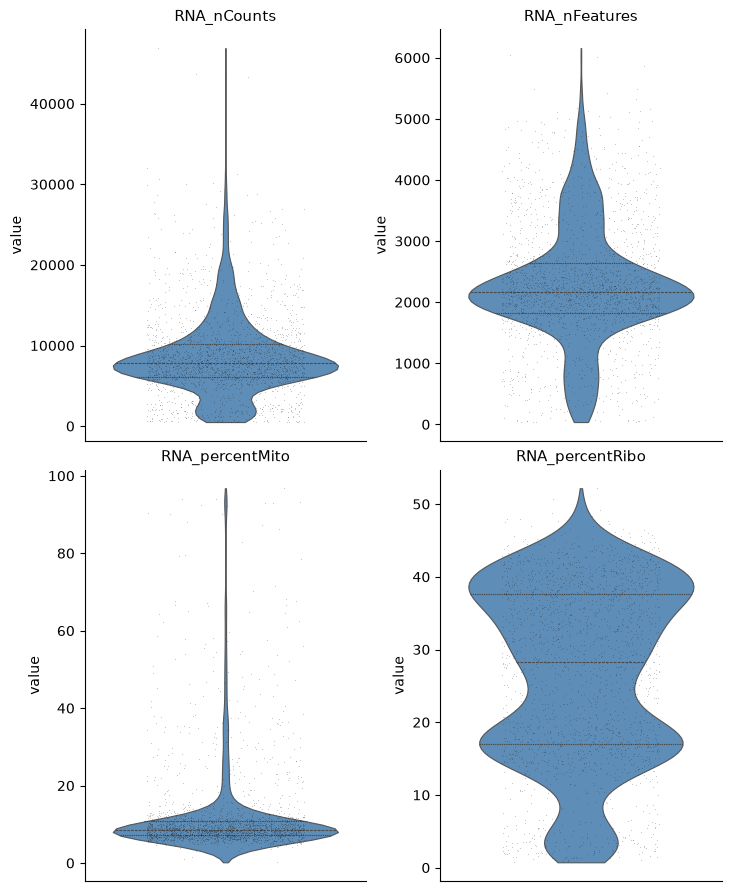

In [5]:
qc_cols = [
    c
    for c in ("RNA_nCounts", "RNA_nFeatures", "RNA_percentMito", "RNA_percentRibo")
    if c in ds.cells.columns
]
qc_cell_selection = ds.snapshot_cell_selection("I")
ds.plots.distribution(
    keys=qc_cols,
    cell_selection=qc_cell_selection,
    kind="violin",
    max_points=2000,
)

In [6]:
manual_filter = {
    "method": "manual",
    "attrs": ["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    "highs": [15000, 4000, 15],
    "lows": [1000, 500, 0],
}

In [7]:
run = ds.pipeline.run(
    filtering=manual_filter,
    hvg_count=500,
    pca_dims=15,
    neighbors_k=11,
    leiden={"partitions": [0.5]},
    cell_cycle=False,
    paris=False,
    doublets=False,
    markers=True,
    snapshot_columns=qc_cols,
)

graph_ref = run["connectivity_map"]
leiden = run["clusters"]
marker_ref = run["markers"]

cell_mask = run.cells.fetch_all("I")
print(f"Cells in input selection: {int(ds.cells.fetch_all('I').sum())}")
print(f"Cells after filter: {int(cell_mask.sum())}")
print(f"Excluded cells: {int((~cell_mask).sum())}; total in store: {len(cell_mask)}")
run.cells.to_pandas_dataframe(qc_cols).describe()

Cells in input selection: 5025
Cells after filter: 3940
Excluded cells: 1085; total in store: 5025


,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo
count,3940.000000,3940.000000,3940.000000,3940.000000
mean,8245.728934,2270.309898,8.575001,30.207449
std,2468.784922,541.559187,2.110144,10.202904
min,1057.000000,512.000000,0.188857,0.737101
25%,6562.000000,1922.000000,7.047202,20.122006
50%,7882.500000,2186.500000,8.364386,32.484297
75%,9606.750000,2527.000000,9.872131,38.770864
max,14992.000000,3930.000000,14.998783,52.181596


In [8]:
print(
    "Selected genes:",
    int(np.count_nonzero(run.features.fetch("highly_variable_features"))),
)
print("HVG artifact:", run["highly_variable_features"])

Selected genes: 500
HVG artifact: ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='79f2bf2b2d6d...')


In [9]:
status = ds.inspect_artifact(run["normalized"])
print("Size factor (ds.RNA.sf):", ds.RNA.sf)
print("cell selection:", status.inputs["cell_selection"])
print("feature selection:", status.inputs["feature_selection"])

Size factor (ds.RNA.sf): 1000
cell selection: {'type': 'artifact', 'scope': 'datastore', 'kind': 'cell_selection', 'artifact_id': '2b20d72a3a0222362df55ff9368f0bc6f89b2b1cec930d4a222b1ff9565ec3e4'}
feature selection: {'type': 'artifact', 'scope': 'assay', 'kind': 'feature_selection', 'artifact_id': '79f2bf2b2d6dfc7e17d6c7fae6acde7fee5edca5bcd70577ab93034f91032921', 'assay': 'RNA'}


In [10]:
pca_status = ds.inspect_artifact(run["pca"])
pca_shape = ds.load_artifact(run["pca"])["data"].shape
graph = ds.load_graph(graph_ref)
degrees = graph.getnnz(axis=1)
print("PCA input:", pca_status.inputs["normalized"])
print("PCA coordinate shape:", pca_shape)
print(graph.shape, graph.nnz)
print(
    "Degree min / median / max:",
    int(degrees.min()),
    int(np.median(degrees)),
    int(degrees.max()),
)

PCA input: {'type': 'artifact', 'scope': 'assay', 'kind': 'normalized', 'artifact_id': '5f677cd3aa4f51b97fc987683dc7b79c522e5e1ddd664b375d000ac105cfa046', 'assay': 'RNA'}
PCA coordinate shape: (3940, 15)
(3940, 3940) 43340
Degree min / median / max: 11 11 11


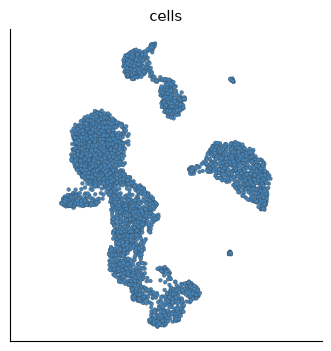

In [11]:
ds.plots.embedding(run=run)

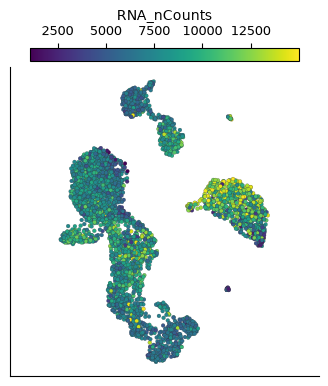

In [12]:
ds.plots.embedding(run=run, color_by="RNA_nCounts")

In [13]:
leiden_values = np.asarray(run.cells.fetch("clusters"))
pd.Series(leiden_values).value_counts().sort_index()

1      694
2       28
3      237
4     1004
5      317
6      539
7      142
8      263
9      378
10     311
11      15
12      12
Name: count, dtype: int64

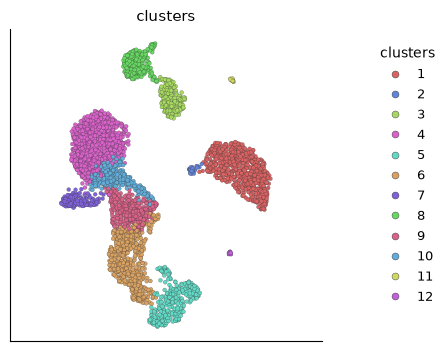

In [14]:
ds.plots.embedding(run=run, color_by="clusters")

In [15]:
paris = ds.run_paris_clustering(graph_ref)
paris_values = np.asarray(ds.load_artifact(paris)["labels"][:])
pd.Series(paris_values).value_counts().sort_index()

1      337
2      385
3      257
4     1269
5      317
6      558
7      137
8      243
9      410
10      15
11      12
Name: count, dtype: int64

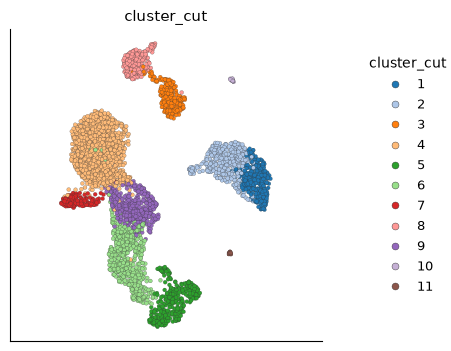

In [16]:
ds.plots.embedding(layout=run["umap"], color_by=paris)

In [17]:
pd.crosstab(
    pd.Series(leiden_values, name="Leiden"),
    pd.Series(paris_values, name="Paris"),
)

Paris,1,2,3,4,5,6,7,8,9,10,11
Leiden,,,,,,,,,,,
1,337,357,0,0,0,0,0,0,0,0,0
2,0,28,0,0,0,0,0,0,0,0,0
3,0,0,236,0,0,0,0,1,0,0,0
4,0,0,0,997,0,7,0,0,0,0,0
5,0,0,0,0,316,1,0,0,0,0,0
6,0,0,0,1,1,499,0,0,38,0,0
7,0,0,0,6,0,0,136,0,0,0,0
8,0,0,21,0,0,0,0,242,0,0,0
9,0,0,0,10,0,51,0,0,317,0,0


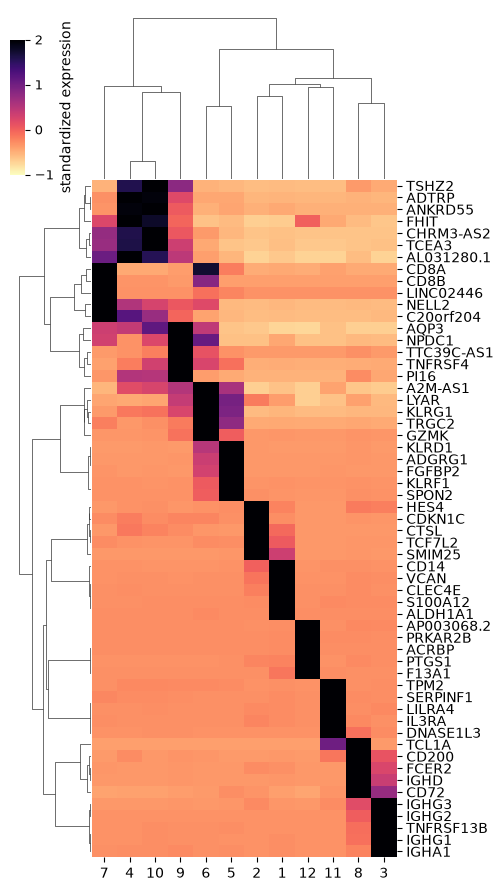

In [18]:
ds.plots.marker_heatmap(marker=marker_ref, topn=5, figsize=(5, 9))

In [19]:
ds.get_markers(marker=marker_ref, group_id="1", min_score=-1, min_frac_exp=-1).head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,1,S100A12,1925,0.93918,1.33633,0.00244,0.95821,0.01356,547.82245,0.0,0.97799,0.0
1,1,VCAN,9167,0.90913,1.49245,0.00502,0.98415,0.03112,297.25199,0.0,0.99135,0.0
2,1,CD14,9635,0.90389,0.93627,0.00273,0.97118,0.01879,343.24257,0.0,0.98481,0.0
3,1,ALDH1A1,16188,0.89359,0.12576,0.00019,0.53458,0.00123,669.70660,0.0,0.76675,0.0
4,1,CLEC4E,20297,0.89341,0.11919,0.00019,0.60231,0.00154,640.17931,0.0,0.80054,0.0


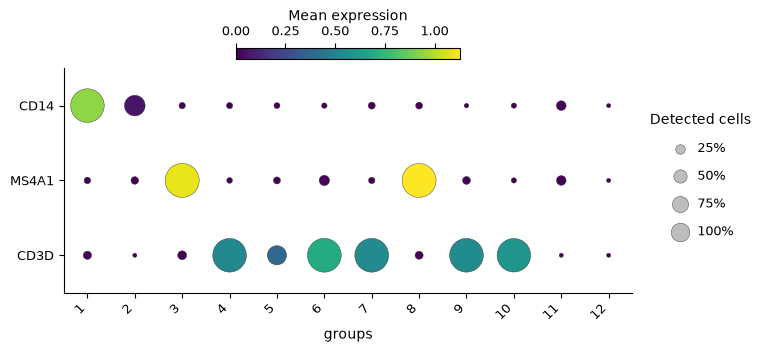

In [20]:
ds.plots.dotplot(
    features=["CD14", "MS4A1", "CD3D"],
    groups=leiden,
)